In [1]:
import numpy as np    
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline    
from RENDES_fizinfo import *

In [2]:
# Gy / 11. feladat [18 p]
# 
# A 9 mm-es Luger Full Metal Jacket lövedékek adatai:
# 
# - tömeg: 7,5 g
# - átmérő: 9,01 mm
# - alaktényező: 0,32
# 
# Tegyük fel, hogy egy ilyen lövedéket 380 m/s-os sebességgel lő ki egy adott puska.
# 
# a) Ha ilyen lövedéket vízszintesen lövünk ki 3 m magasról, 
# akkor a kilövés helyétől milyen távol és milyen sebességgel csapódik a földbe 
# 1,3 kg/m³-es levegősűrűség esetén? [4 p]
# 
# b) Ábrázolja grafikonon a lövedék „esését” az eredeti magassághoz képest 
# a célpont távolsága, azaz x koordinátája függvényében! [2 p]
# 
# c) Ábrázolja grafikonon a lövedék mozgási energiáját a célpont távolsága, 
# azaz x koordinátája függvényében! [2 p]
# 
# d) Ha függőlegesen felfelé lövünk ezzel a fegyverrel, 
# akkor milyen magasságig repül a lövedék, 
# hány másodperc múlva és milyen sebességgel esik vissza? [4 p]
# 
# e) Változtassuk a kilövés vízszintessel bezárt szögét 0 és 90 fok között. 
# Ábrázolja a kilövési szög függvényében a lövés távolságát és a becsapódás sebességét! [4 p]
# 
# f) Milyen kilövési szög esetén maximális a lőtávolság, és mennyi ennek az értéke? [2 p]

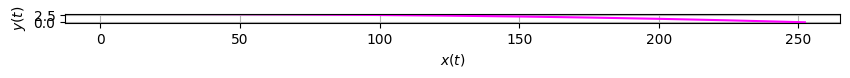

In [3]:
# --- Lovedek fizikai paraméterei ---
m_bullet = 0.0075      # Lovedek tömege [kg] = 5,7 g
d_bullet = 0.0091      # Lovedek átmérője [m] = 67 mm
r_bullet = d_bullet / 2 # Lovedek sugara [m]

A_bullet = np.pi * r_bullet**2  # keresztmetszeti felület [m^2]

C_bullet = 0.32       # alaktényező / közegellenállási tényező [-]
rho_air = 1.3        # levegő sűrűsége normál körülmények között [kg/m^3]
g = 9.81            # gravitációs gyorsulás [m/s^2]

def create_grav_közeg_F_m(m, C, A, rho, g=9.81):
    """Egy konstans tömegű test tömege és a rá ható erő gravitációs tér és közegellenállás jelenlétében."""

    def mass_fun(t):   
        return m

    def force_fun(t, r, v, m):
        """Gravitációs erő y irányban és v^2-tel arányos közegellenállási erő eredője."""
        
        F_work=np.array([0.0, -m*g], np.float64) 
        v_abs=((v**2).sum())**0.5
        F_work-=0.5*C*A*rho*v*v_abs
    
        return F_work

    return force_fun, mass_fun

# --- Gravitáció + közegellenállás erőfüggvény létrehozása ---
F_bullet, m_const_bullet = create_grav_közeg_F_m(
    m=m_bullet,       # test tömege [kg]
    C=C_bullet,       # alaktényező [-]
    A=A_bullet,       # keresztmetszeti felület [m^2]
    rho=rho_air,    # levegő sűrűsége [kg/m^3]
    g=g             # gravitációs gyorsulás [m/s^2]
)


# --- Kezdőfeltételek ---
kezdo_x = 0.0       # kezdeti x pozíció [m]
kezdo_y = 3.0       # kezdeti y pozíció [m] = 300 cm azaz 3 m

indulo_sebesseg = 380.0   # kezdősebesség nagysága [m/s]
indulo_szog_fok = 0.0     # indulási szög a vízszintestől mérve [°]


# Sebességvektor felbontása x és y komponensre a szög alapján:
kezdo_vx = indulo_sebesseg * np.cos(np.radians(indulo_szog_fok))  # vízszintes sebesség [m/s]
kezdo_vy = indulo_sebesseg * np.sin(np.radians(indulo_szog_fok))  # függőleges sebesség [m/s]


# --- Egyszerű leállási feltétel: ha y < 0, akkor stop ---
def stop_ground_y(r, v):
    """Leállás y < 0 esetén."""
    
    return r[1] < 0.0


# --- Szimuláció előkészítése ---
bullet_din = num_dinam(2)                    # 2D mozgás (x-y sík)
bullet_din.set_time_range(0.0, 360.0, 0.0001)  # t ∈ [0, 30] s, dt = 0.0001 s

bullet_din.set_F_fun(F_bullet)                 # erőfüggvény: gravitáció + közegellenállás
bullet_din.set_mass_fun(m_const_bullet)        # konstans tömegfüggvény

bullet_din.set_r0_v0(
    [kezdo_x, kezdo_y],                    # kezdeti helyzet [m]
    [kezdo_vx, kezdo_vy]                   # kezdeti sebesség [m/s]
)

bullet_din.set_stop_cond(stop_ground_y)      # megállás, ha a labda eléri a talajt

bullet_din.full_dinam_calc()

bullet_din.plot_rcomp()                      # x(t) és y(t) komponensek külön ábrán

In [4]:
# a) Ha ilyen lövedéket vízszintesen lövünk ki 3 m magasról, 
# akkor a kilövés helyétől milyen távol és milyen sebességgel csapódik a földbe 
# 1,3 kg/m³-es levegősűrűség esetén? [4 p]

print(f'A kilövéstől x irányban {bullet_din.r_x[-1]:.2f} m')
print(f'A sebessége ilyenkor {bullet_din.v_abs[-1]:.2f} m/s')

A kilövéstől x irányban 252.31 m
A sebessége ilyenkor 241.14 m/s


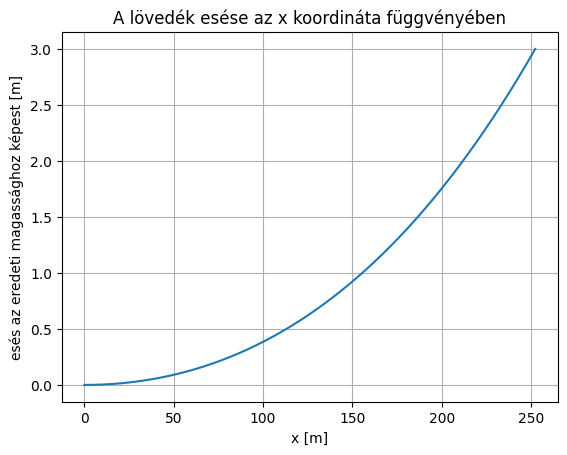

In [5]:
# b) Ábrázolja grafikonon a lövedék „esését” az eredeti magassághoz képest 
# a célpont távolsága, azaz x koordinátája függvényében! [2 p]

# Az indulási magassághoz viszonyított függőleges esés [m].
# Kezdetben 0, becsapódáskor vízszintes kilövésnél kb. a kezdo_y értékével egyezik meg.
eses = kezdo_y - bullet_din.r_y

plt.figure()
plt.plot(bullet_din.r_x, eses)

plt.xlabel("x [m]")
plt.ylabel("esés az eredeti magassághoz képest [m]")
plt.title("A lövedék esése az x koordináta függvényében")

plt.grid(True)
plt.show()

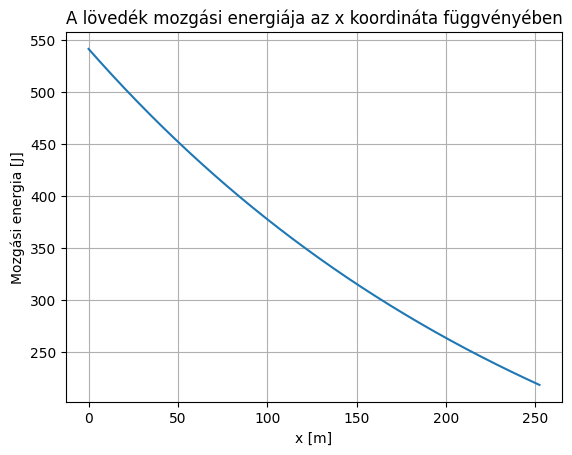

In [6]:
# c) Ábrázolja grafikonon a lövedék mozgási energiáját a célpont távolsága, 
# azaz x koordinátája függvényében! [2 p]

E_mozgasi = bullet_din.kinetic_energy_constant_m(m_bullet)

plt.figure()
plt.plot(bullet_din.r_x, E_mozgasi)

plt.xlabel("x [m]")
plt.ylabel("Mozgási energia [J]")
plt.title("A lövedék mozgási energiája az x koordináta függvényében")

plt.grid(True)
plt.show()

In [7]:
# d) Ha függőlegesen felfelé lövünk ezzel a fegyverrel, 
# akkor milyen magasságig repül a lövedék, 
# hány másodperc múlva és milyen sebességgel esik vissza? [4 p]

indulo_szog_fok = 90.0     # indulási szög a vízszintestől mérve [°]

# Sebességvektor felbontása x és y komponensre a szög alapján:
kezdo_vx = indulo_sebesseg * np.cos(np.radians(indulo_szog_fok))  # vízszintes sebesség [m/s]
kezdo_vy = indulo_sebesseg * np.sin(np.radians(indulo_szog_fok))  # függőleges sebesség [m/s]

# --- Szimuláció előkészítése ---
bullet_din90 = num_dinam(2)                    # 2D mozgás (x-y sík)
bullet_din90.set_time_range(0.0, 360.0, 0.0001)  # t ∈ [0, 30] s, dt = 0.0001 s

bullet_din90.set_F_fun(F_bullet)                 # erőfüggvény: gravitáció + közegellenállás
bullet_din90.set_mass_fun(m_const_bullet)        # konstans tömegfüggvény

bullet_din90.set_r0_v0(
    [kezdo_x, kezdo_y],                    # kezdeti helyzet [m]
    [kezdo_vx, kezdo_vy]                   # kezdeti sebesség [m/s]
)
bullet_din90.set_stop_cond(stop_ground_y) 
bullet_din90.full_dinam_calc()
#bullet_din90.plot_rcomp() #ellenorizzuk hogy nem csináltunk-e hülyeséget!!!!!!!!!!!

In [8]:
maxindex = bullet_din90.r_y.argmax()

print(f'A golyó maximális y irányú pozíciója: {bullet_din90.r_y[maxindex]:.2f} m')
print(f'A golyó {bullet_din90.t[maxindex]:.2f} s múlva kezdi meg a visszaesést.')
print(f'A golyó {bullet_din90.t[-1]:.2f} s múlva esik vissza a talajra.')
print(f'A golyó visszaesési / becsapódási sebessége: {bullet_din90.v_abs[-1]:.2f} m/s')

A golyó maximális y irányú pozíciója: 922.16 m
A golyó 10.37 s múlva kezdi meg a visszaesést.
A golyó 28.01 s múlva esik vissza a talajra.
A golyó visszaesési / becsapódási sebessége: 72.41 m/s


In [9]:
# e) Változtassuk a kilövés vízszintessel bezárt szögét 0 és 90 fok között. 
# Ábrázolja a kilövési szög függvényében a lövés távolságát és a becsapódás sebességét! [4 p]

def bullet_szim(szog_fok, dt=0.01, t_max=100.0):
    # A kezdősebesség nagysága minden szögnél ugyanaz, csak az x-y komponensek változnak.
    vx0 = indulo_sebesseg * np.cos(np.radians(szog_fok))
    vy0 = indulo_sebesseg * np.sin(np.radians(szog_fok))
    
    # Minden szöghöz új objektumot készítünk, hogy a korábbi futások ne keveredjenek bele.
    bullet_szim_obj = num_dinam(2)
    bullet_szim_obj.set_time_range(0.0, t_max, dt)
    bullet_szim_obj.set_F_fun(F_bullet)
    bullet_szim_obj.set_mass_fun(m_const_bullet)
    bullet_szim_obj.set_r0_v0([kezdo_x, kezdo_y], [vx0, vy0])
    bullet_szim_obj.stop_cond = stop_ground_y
    
    # Teljes dinamikai számítás a becsapódásig.
    bullet_szim_obj.full_dinam_calc()
    
    # Sebességnagyság, mert a feladat maximumsebességet kér.
    return bullet_szim_obj


# A kilövési szögeket 0 és 90 fok között vizsgáljuk.
# A 0.1 fokos felbontás elég részletes ahhoz, hogy jól látszódjon a maximum helye.
szogek = np.arange(0.0, 90.0 + 0.1, 0.1)
max_tavolsagok = []
max_becsap_seb = []

for szog in szogek:
    bullet_szim_obj = bullet_szim(szog)
    
    max_tavolsagok.append(bullet_szim_obj.r_x.max())
    max_becsap_seb.append(bullet_szim_obj.v_abs[-1])


max_tavolsagok = np.array(max_tavolsagok)
max_becsap_seb = np.array(max_becsap_seb)

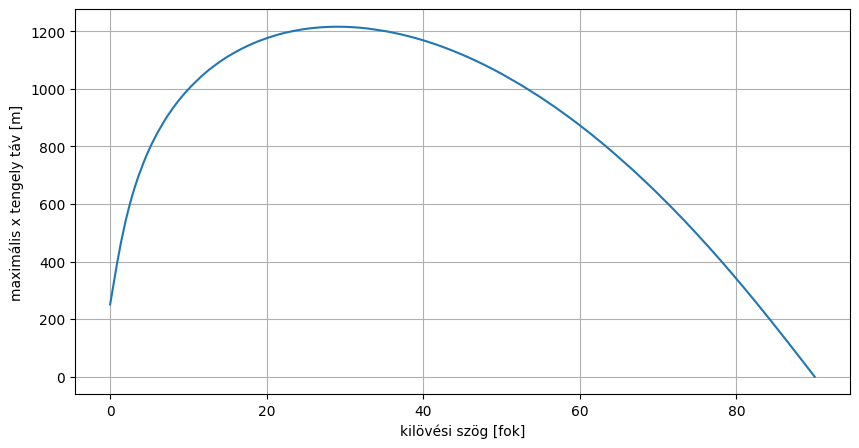

In [10]:
fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(111)

ax1.plot(szogek, max_tavolsagok)
ax1.set_xlabel('kilövési szög [fok]')
ax1.set_ylabel('maximális x tengely táv [m]')
ax1.grid()

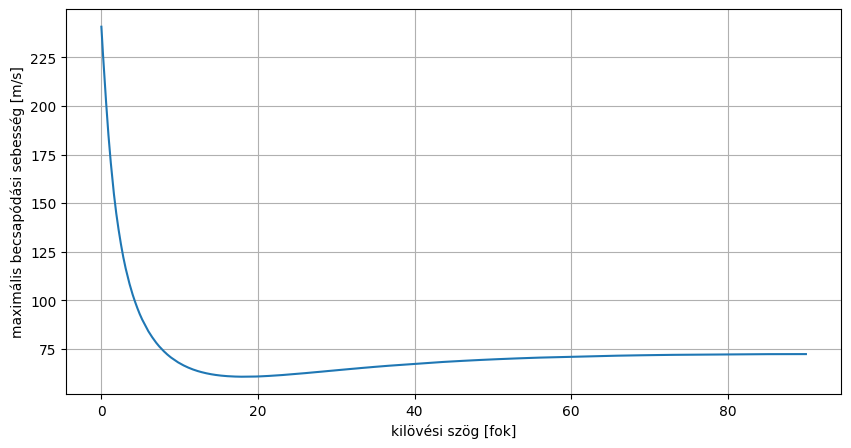

In [11]:
fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(111)

ax1.plot(szogek, max_becsap_seb)
ax1.set_xlabel('kilövési szög [fok]')
ax1.set_ylabel('maximális becsapódási sebesség [m/s]')
ax1.grid()

In [12]:
# f) Milyen kilövési szög esetén maximális a lőtávolság, és mennyi ennek az értéke? [2 p]

print(f'Ennel a szognel: {szogek[max_tavolsagok.argmax()]}°')
print(f'Max tav: {max_tavolsagok.max():.2f} méter')


Ennel a szognel: 29.0°
Max tav: 1215.93 méter
